# SCPMNet Scan Annotation Viewer

Visualize all annotated nodules for one LIDC/SCPMNet scan in full-volume voxel coordinates. The viewer uses the same `z, y, x` convention as `SCPMNet/dataset.py`.

In [71]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from IPython.display import display

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src" / "det" / "SCPMNet").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.det.SCPMNet.dataset import load_volume, normalize_ct, resolve_image_path


## Configuration

Set `SCAN_ID` to the scan you want to inspect. If it is `None`, the notebook uses the first scan in the selected split.

In [72]:
CSV_PATH = REPO_ROOT / "data/lidc_process/lidc_labels.csv"
DATA_ROOT = REPO_ROOT / "data/lidc_process"
PREDICTIONS_PATH = REPO_ROOT / "outputs/scpmnet/scpmnet_paper/predictions/test_predictions.csv" #fp_reduction/rescored_test/test_predictions_rescored.csv"
PREDICTIONS_PATH = REPO_ROOT / "outputs/scpmnet/scpmnet_paper/fp_reduction/rescored_test/test_predictions_rescored.csv"

SCAN_ID = "LIDC-IDRI-0020"  # Example: "LIDC-IDRI-0020". None auto-picks the first locally available scan.
SPLIT = None  # Example: "train", "val", "test", or None for all splits.
AUTO_FALLBACK_IF_VOLUME_MISSING = True
CLIP = (-1000.0, 400.0)

SHOW_PREDICTIONS = True
PREDICTION_SCORE_THRESHOLD = 0.2
MAX_PREDICTIONS = 200


## Load Scan

In [73]:
labels_df = pd.read_csv(CSV_PATH)
if SPLIT is not None:
    labels_df = labels_df[labels_df["split"].astype(str) == str(SPLIT)].copy()


def rows_for_scan(scan_id):
    rows = labels_df[labels_df["seriesuid"].astype(str) == str(scan_id)].copy()
    if rows.empty:
        raise ValueError(f"No labels found for SCAN_ID={scan_id!r} with SPLIT={SPLIT!r}")
    return rows


def find_available_scan():
    for candidate_scan_id, candidate_rows in labels_df.groupby("seriesuid", sort=False):
        candidate_path = resolve_image_path(candidate_rows.iloc[0], DATA_ROOT)
        if Path(candidate_path).exists():
            return str(candidate_scan_id), candidate_rows.copy(), candidate_path
    raise FileNotFoundError(f"No locally available scan volumes found for CSV_PATH={CSV_PATH}")


if SCAN_ID is None:
    SCAN_ID, scan_rows, image_path = find_available_scan()
else:
    scan_rows = rows_for_scan(SCAN_ID)
    image_path = resolve_image_path(scan_rows.iloc[0], DATA_ROOT)
    if not Path(image_path).exists() and AUTO_FALLBACK_IF_VOLUME_MISSING:
        requested_scan_id = SCAN_ID
        SCAN_ID, scan_rows, image_path = find_available_scan()
        print(f"Requested scan {requested_scan_id!r} has no local volume at {image_path}; using available scan {SCAN_ID!r} instead.")
    elif not Path(image_path).exists():
        raise FileNotFoundError(f"Volume for SCAN_ID={SCAN_ID!r} not found: {image_path}")

volume = normalize_ct(load_volume(image_path), CLIP)

print("Scan:", SCAN_ID)
print("Split:", scan_rows["split"].iloc[0] if "split" in scan_rows.columns else None)
print("Image path:", image_path)
print("Volume shape [Z, Y, X]:", volume.shape)
print("Annotated rows:", len(scan_rows))


Scan: LIDC-IDRI-0020
Split: None
Image path: /Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/data/lidc_process/LIDC-IDRI-0020/LIDC-IDRI-0020_volume.nii.gz
Volume shape [Z, Y, X]: (257, 203, 257)
Annotated rows: 2


## Build Annotation Spheres

In [74]:
def row_radius(row):
    if "radius" in row and pd.notna(row["radius"]):
        return float(row["radius"])
    for diameter_col in ("diameter", "diameter_mm"):
        if diameter_col in row and pd.notna(row[diameter_col]):
            return float(row[diameter_col]) / 2.0
    depth_col = "depth" if "depth" in row and pd.notna(row.get("depth")) else "d"
    dims = []
    for col in ("w", "h", depth_col):
        if col in row and pd.notna(row[col]):
            dims.append(float(row[col]))
    return max(dims) / 2.0 if len(dims) == 3 else 0.0


def annotations_from_rows(rows):
    if all(col in rows.columns for col in ("coordZ", "coordY", "coordX")):
        coord_cols = ("coordZ", "coordY", "coordX")
    elif all(col in rows.columns for col in ("z", "y", "x")):
        coord_cols = ("z", "y", "x")
    else:
        raise ValueError("Expected coordZ/coordY/coordX or z/y/x columns.")

    valid = rows.dropna(subset=list(coord_cols)).copy()
    if "label" in valid.columns:
        valid = valid[valid["label"].astype(str).str.lower().isin(("nodule", "1", "true", "positive"))].copy()
    spheres = []
    for idx, row in valid.iterrows():
        radius = row_radius(row)
        if radius > 0:
            spheres.append({
                "source_row": idx,
                "coordZ": float(row[coord_cols[0]]),
                "coordY": float(row[coord_cols[1]]),
                "coordX": float(row[coord_cols[2]]),
                "radius": float(radius),
                "w": float(row["w"]) if "w" in row and pd.notna(row["w"]) else np.nan,
                "h": float(row["h"]) if "h" in row and pd.notna(row["h"]) else np.nan,
                "d": float(row["d"]) if "d" in row and pd.notna(row["d"]) else np.nan,
            })
    return pd.DataFrame(spheres)


annots_df = annotations_from_rows(scan_rows)
display(annots_df)
annots = annots_df[["coordZ", "coordY", "coordX", "radius"]].to_numpy(dtype=np.float32)

preds = np.zeros((0, 5), dtype=np.float32)
if SHOW_PREDICTIONS and PREDICTIONS_PATH and Path(PREDICTIONS_PATH).exists():
    pred_df = pd.read_csv(PREDICTIONS_PATH)
    pred_df = pred_df[pred_df["seriesuid"].astype(str) == str(SCAN_ID)].copy()
    pred_df = pred_df[pred_df["probability"] >= float(PREDICTION_SCORE_THRESHOLD)].copy()
    pred_df = pred_df.sort_values("probability", ascending=False).head(MAX_PREDICTIONS)
    preds = pred_df[["coordZ", "coordY", "coordX", "radius", "probability"]].to_numpy(dtype=np.float32)
    print(f"Loaded {len(preds)} predictions for this scan.")
elif SHOW_PREDICTIONS:
    print(f"Predictions file not found: {PREDICTIONS_PATH}")

,source_row,coordZ,coordY,coordX,radius,w,h,d
0,62,177.513031,136.644348,174.414413,10.521418,21.042835,21.042835,21.042835
1,63,218.333328,90.151512,169.530304,2.589795,5.179590,5.179590,5.179590


Loaded 3 predictions for this scan.


## Viewer

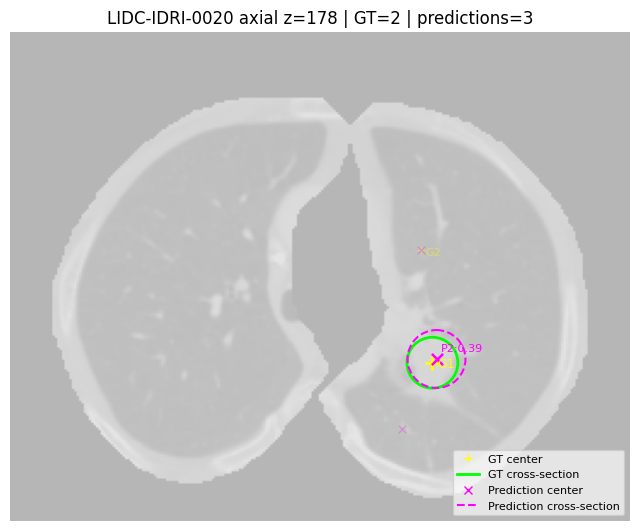

In [75]:
def display_image(slice_2d):
    return np.clip((slice_2d + 1.0) / 2.0, 0.0, 1.0)


def cross_section_radius(center, radius, axis_value):
    delta = abs(float(center) - float(axis_value))
    if delta > float(radius):
        return None
    return max(float(radius) ** 2 - delta ** 2, 0.0) ** 0.5


def plot_axial(z=None, figsize=(8, 8), show_off_slice=True):
    if z is None:
        z = int(round(annots[0, 0])) if len(annots) else volume.shape[0] // 2
    z = int(np.clip(z, 0, volume.shape[0] - 1))

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(display_image(volume[z]), cmap="gray", vmin=0, vmax=1)

    for n, (cz, cy, cx, radius) in enumerate(annots, start=1):
        sr = cross_section_radius(cz, radius, z)
        if sr is None:
            if show_off_slice:
                ax.scatter([cx], [cy], marker="+", c="yellow", s=35, linewidths=1.0, alpha=0.35)
                ax.text(cx + 2, cy + 2, f"G{n}", color="yellow", fontsize=8, alpha=0.45)
            continue
        ax.add_patch(Circle((cx, cy), max(sr, 1.5), fill=False, color="lime", linewidth=2.0))
        ax.scatter([cx], [cy], marker="+", c="yellow", s=90, linewidths=2.0)
        ax.text(cx + 2, cy + 2, f"G{n}", color="yellow", fontsize=9)

    for n, (cz, cy, cx, radius, score) in enumerate(preds, start=1):
        sr = cross_section_radius(cz, radius, z)
        if sr is None:
            if show_off_slice:
                ax.scatter([cx], [cy], marker="x", c="magenta", s=30, linewidths=1.0, alpha=0.25)
            continue
        ax.add_patch(Circle((cx, cy), max(sr, 1.5), fill=False, color="magenta", linewidth=1.5, linestyle="--"))
        ax.scatter([cx], [cy], marker="x", c="magenta", s=65, linewidths=1.8)
        ax.text(cx + 2, cy - 3, f"P{n}:{score:.2f}", color="magenta", fontsize=8)

    ax.set_title(f"{SCAN_ID} axial z={z} | GT={len(annots)} | predictions={len(preds)}")
    ax.set_xlim(0, volume.shape[2] - 1)
    ax.set_ylim(volume.shape[1] - 1, 0)
    ax.set_axis_off()
    ax.legend(
        handles=[
            Line2D([0], [0], marker="+", color="yellow", linestyle="None", label="GT center"),
            Line2D([0], [0], color="lime", linewidth=2, label="GT cross-section"),
            Line2D([0], [0], marker="x", color="magenta", linestyle="None", label="Prediction center"),
            Line2D([0], [0], color="magenta", linewidth=1.5, linestyle="--", label="Prediction cross-section"),
        ],
        loc="lower right",
        fontsize=8,
        framealpha=0.65,
    )
    plt.show()


plot_axial()

## Interactive Axial Slider

In [76]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    z0 = int(round(annots[0, 0])) if len(annots) else volume.shape[0] // 2
    z_widget = widgets.IntSlider(value=z0, min=0, max=volume.shape[0] - 1, step=1, description="z")
    off_slice_widget = widgets.Checkbox(value=True, description="off-slice centers")
    out = widgets.interactive_output(plot_axial, {"z": z_widget, "show_off_slice": off_slice_widget})
    display(widgets.HBox([z_widget, off_slice_widget]), out)
except ImportError:
    print("ipywidgets is not installed. Use plot_axial(z=...) manually.")

Output()

## Quick Manual Calls

In [77]:
# Examples:
# plot_axial(z=100)
# plot_axial(z=int(round(annots[0, 0])), show_off_slice=False)